<a href="https://colab.research.google.com/github/alfred624/ardhi/blob/main/Financial_health_prediction_challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Train.csv to Train (22).csv
Shape: (9618, 39)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9618 entries, 0 to 9617
Data columns (total 39 columns):
 #   Column                                                            Non-Null Count  Dtype  
---  ------                                                            --------------  -----  
 0   ID                                                                9618 non-null   object 
 1   country                                                           9618 non-null   object 
 2   owner_age                                                         9618 non-null   float64
 3   attitude_stable_business_environment                              9616 non-null   object 
 4   attitude_worried_shutdown                                         9616 non-null   object 
 5   compliance_income_tax                                             9614 non-null   object 
 6   perception_insurance_doesnt_cover_losses                          9613 non-

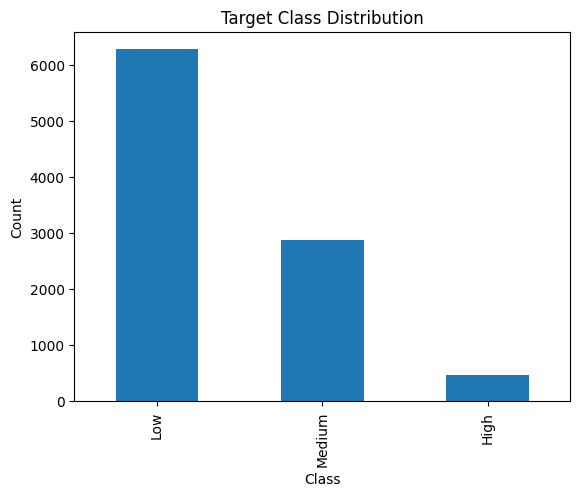

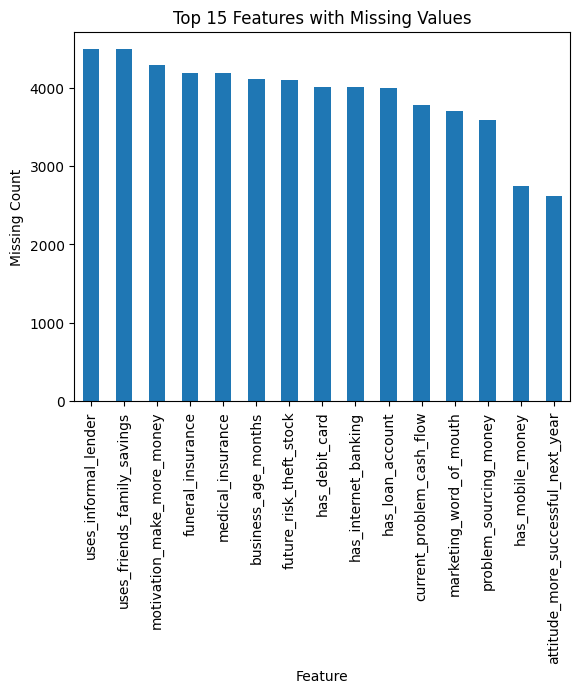

              precision    recall  f1-score   support

        High       0.92      0.61      0.73        94
         Low       0.88      0.97      0.92      1256
      Medium       0.86      0.70      0.77       574

    accuracy                           0.87      1924
   macro avg       0.88      0.76      0.81      1924
weighted avg       0.87      0.87      0.87      1924

Macro F1 Score: 0.8073105852830104


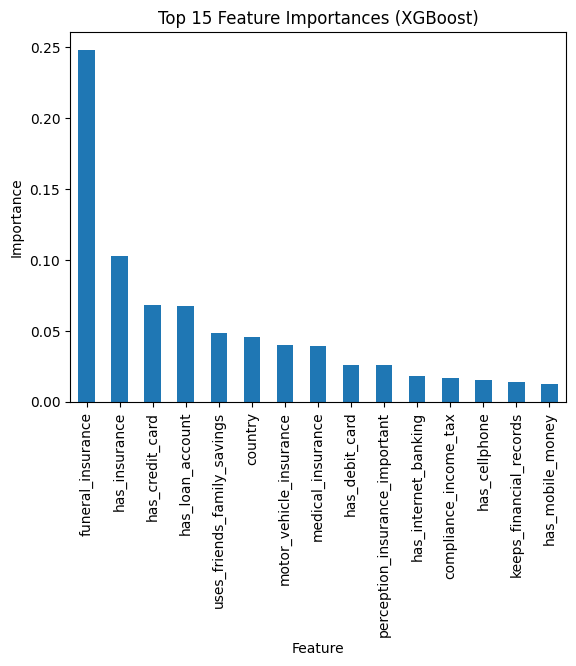

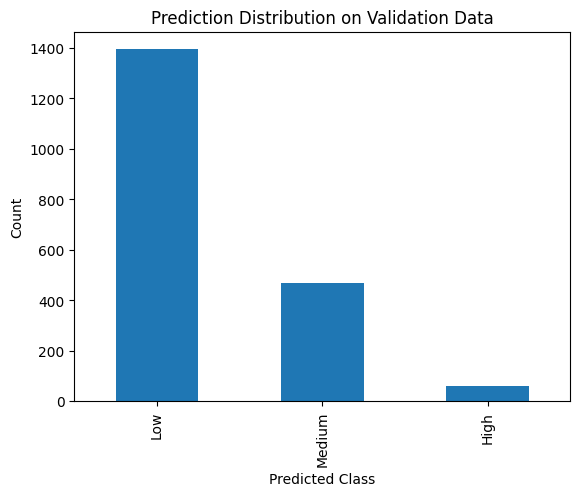

Final model trained on full dataset


In [29]:

from google.colab import files
uploaded = files.upload()


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score

from xgboost import XGBClassifier


train = pd.read_csv("Train.csv")

print("Shape:", train.shape)
train.head()

train.info()


print(train["Target"].value_counts())

train.isnull().sum().sort_values(ascending=False)


plt.figure()
train["Target"].value_counts().plot(kind="bar")
plt.title("Target Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

missing = train.isnull().sum().sort_values(ascending=False).head(15)

plt.figure()
missing.plot(kind="bar")
plt.title("Top 15 Features with Missing Values")
plt.xlabel("Feature")
plt.ylabel("Missing Count")
plt.show()



X = train.drop(columns=["ID", "Target"])
y = train["Target"]

label_encoders = {}

for col in X.select_dtypes(include="object").columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

target_le = LabelEncoder()
y = target_le.fit_transform(y)


X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_val)

print(classification_report(
    y_val, y_pred,
    target_names=target_le.classes_
))

print("Macro F1 Score:", f1_score(y_val, y_pred, average="macro"))


importances = model.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importances, index=feature_names)\
             .sort_values(ascending=False)\
             .head(15)

plt.figure()
feat_imp.plot(kind="bar")
plt.title("Top 15 Feature Importances (XGBoost)")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.show()


pred_labels = target_le.inverse_transform(y_pred)

plt.figure()
pd.Series(pred_labels).value_counts().plot(kind="bar")
plt.title("Prediction Distribution on Validation Data")
plt.xlabel("Predicted Class")
plt.ylabel("Count")
plt.show()


model.fit(X, y)

print("Final model trained on full dataset")
